# MNIST neural network from scratch

Build a handwritten-digit classifier with NumPy while inspecting every important representation, calculation, gradient, and experiment.

In [4]:
import sys
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)

Python: 3.14.7
NumPy: 2.5.3


In [5]:
test_rng = np.random.default_rng(SEED)
print(test_rng.random(3))

[0.77395605 0.43887844 0.85859792]


In [7]:
print("X shape:", X_raw.shape)
print("y shape:", y_raw.shape)
print("pixel range:", X_raw.min(), X_raw.max())
print("labels:", np.unique(y_raw))

X shape: (70000, 784)
y shape: (70000,)
pixel range: 0 255
labels: [0 1 2 3 4 5 6 7 8 9]


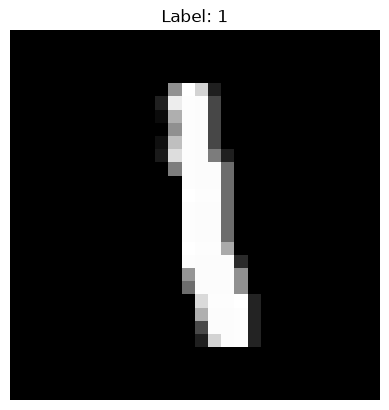

In [8]:
index = 6
image = X_raw[index].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(f"Label: {y_raw[index]}")
plt.axis("off")
plt.show()

## 3. Prepare the data

In [14]:
X_train_full = X_raw[:60_000]
y_train_full = y_raw[:60_000]
X_test_raw = X_raw[60_000:]
y_test = y_raw[60_000:]

indices = rng.permutation(len(X_train_full))
validation_indices = indices[:10_000]
training_indices = indices[10_000:]

X_validation_raw = X_train_full[validation_indices]
y_validation = y_train_full[validation_indices]
X_train_raw = X_train_full[training_indices]
y_train = y_train_full[training_indices]

In [15]:
X_train = (X_train_raw / 255.0).astype(np.float32).T
X_validation = (X_validation_raw / 255.0).astype(np.float32).T
X_test = (X_test_raw / 255.0).astype(np.float32).T

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_validation.shape, y_validation.shape)
print("Test:", X_test.shape, y_test.shape)
print("Data type:", X_train.dtype)
print("Pixel range:", X_train.min(), X_train.max())

Train: (784, 50000) (50000,)
Validation: (784, 10000) (10000,)
Test: (784, 10000) (10000,)
Data type: float32
Pixel range: 0.0 1.0


In [16]:
# Strategy 1: choose a random digit for every validation image.
random_predictions = rng.integers(0, 10, size=y_validation.shape)
random_accuracy = np.mean(random_predictions == y_validation)

# Strategy 2: always choose the most frequent training digit.
digit_counts = np.bincount(y_train)
majority_digit = np.argmax(digit_counts)
majority_accuracy = np.mean(y_validation == majority_digit)

print("Random baseline:", random_accuracy)
print("Majority digit:", majority_digit)
print("Majority baseline:", majority_accuracy)

Random baseline: 0.098
Majority digit: 1
Majority baseline: 0.105


In [17]:
def initialize_parameters(generator, input_size=784, hidden_size=10, output_size=10):
    # Random weights break symmetry; the scale keeps initial values controlled.
    W1 = (
        generator.standard_normal((hidden_size, input_size))
        * np.sqrt(2 / input_size)
    ).astype(np.float32)
    b1 = np.zeros((hidden_size, 1), dtype=np.float32)

    W2 = (
        generator.standard_normal((output_size, hidden_size))
        * np.sqrt(2 / hidden_size)
    ).astype(np.float32)
    b2 = np.zeros((output_size, 1), dtype=np.float32)

    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


parameters = initialize_parameters(np.random.default_rng(SEED))

for name, value in parameters.items():
    print(name, value.shape)

W1 (10, 784)
b1 (10, 1)
W2 (10, 10)
b2 (10, 1)


In [18]:
def relu(Z):
    return np.maximum(0, Z)  # Replace negative values with zero.


def softmax(Z):
    shifted = Z - np.max(Z, axis=0, keepdims=True)  # Prevent exponential overflow.
    exponentials = np.exp(shifted)
    return exponentials / np.sum(exponentials, axis=0, keepdims=True)


def forward(X, parameters):
    Z1 = parameters["W1"] @ X + parameters["b1"]  # Weighted input to hidden layer.
    A1 = relu(Z1)                                  # Hidden-layer activations.
    Z2 = parameters["W2"] @ A1 + parameters["b2"] # Ten output scores, or logits.
    A2 = softmax(Z2)                               # Ten probabilities per image.

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache


one_image = X_train[:, :1]                         # Shape: 784 × 1.
probabilities, cache = forward(one_image, parameters)

print("Probability shape:", probabilities.shape)
print("Probability sum:", probabilities.sum())
print("Predicted digit:", np.argmax(probabilities))
print("Actual digit:", y_train[0])

Probability shape: (10, 1)
Probability sum: 0.9999999
Predicted digit: 0
Actual digit: 4


In [20]:
def one_hot(labels, number_of_classes=10):
    # Create one column per label, initially filled with zeros.
    encoded = np.zeros((number_of_classes, labels.size), dtype=np.float32)

    # Put 1 at the correct class position in every column.
    encoded[labels, np.arange(labels.size)] = 1.0
    return encoded


def cross_entropy(probabilities, labels):
    # Avoid log(0), which is undefined.
    clipped = np.clip(probabilities, 1e-12, 1.0)

    # Select the probability assigned to each example's correct digit.
    target_probabilities = clipped[labels, np.arange(labels.size)]

    # High correct-class probability gives low loss; low probability gives high loss.
    return -np.mean(np.log(target_probabilities))


one_image_loss = cross_entropy(probabilities, y_train[:1])
print("One-image loss:", one_image_loss)
print("Uniform-guess reference:", np.log(10))

One-image loss: 2.7036407
Uniform-guess reference: 2.302585092994046


dZ2 = A2 - one_hot(Y)
dW2 = dZ2 A1ᵀ / m          db2 = sum(dZ2) / m
dZ1 = W2ᵀdZ2 ⊙ ReLU′(Z1)
dW1 = dZ1 Xᵀ / m           db1 = sum(dZ1) / m

In [21]:
def backward(X, labels, parameters, cache):
    batch_size = X.shape[1]

    # Output-layer error: predicted probabilities minus correct one-hot labels.
    dZ2 = cache["A2"] - one_hot(labels)
    dW2 = (dZ2 @ cache["A1"].T) / batch_size
    db2 = np.sum(dZ2, axis=1, keepdims=True) / batch_size

    # Carry output error backward through W2 and the ReLU gate.
    dA1 = parameters["W2"].T @ dZ2
    dZ1 = dA1 * (cache["Z1"] > 0)
    dW1 = (dZ1 @ X.T) / batch_size
    db1 = np.sum(dZ1, axis=1, keepdims=True) / batch_size

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}


small_batch = X_train[:, :8]
small_labels = y_train[:8]
_, small_cache = forward(small_batch, parameters)
gradients = backward(small_batch, small_labels, parameters, small_cache)

for name, value in parameters.items():
    gradient = gradients["d" + name]
    print(name, value.shape, "gradient", gradient.shape, "finite", np.isfinite(gradient).all())

W1 (10, 784) gradient (10, 784) finite True
b1 (10, 1) gradient (10, 1) finite True
W2 (10, 10) gradient (10, 10) finite True
b2 (10, 1) gradient (10, 1) finite True


In [22]:
def accuracy(probabilities, labels):
    predictions = np.argmax(probabilities, axis=0)
    return np.mean(predictions == labels)


def update_parameters(parameters, gradients, learning_rate):
    # Move every parameter opposite its loss gradient.
    return {
        "W1": parameters["W1"] - learning_rate * gradients["dW1"],
        "b1": parameters["b1"] - learning_rate * gradients["db1"],
        "W2": parameters["W2"] - learning_rate * gradients["dW2"],
        "b2": parameters["b2"] - learning_rate * gradients["db2"],
    }


def train(X, labels, hidden_size=10, learning_rate=0.1,
          steps=500, log_every=50, seed=SEED):
    # Reinitialize so each training run begins from a known state.
    local_rng = np.random.default_rng(seed)
    parameters = initialize_parameters(local_rng, hidden_size=hidden_size)
    history = []

    for step in range(steps + 1):
        probabilities, cache = forward(X, parameters)

        # Record progress without printing on every update.
        if step % log_every == 0:
            loss = cross_entropy(probabilities, labels)
            score = accuracy(probabilities, labels)
            history.append((step, loss, score))
            print(f"step {step:4d} | loss {loss:.4f} | accuracy {score:.3f}")

        if step == steps:
            break

        gradients = backward(X, labels, parameters, cache)
        parameters = update_parameters(parameters, gradients, learning_rate)

    return parameters, np.array(history)


def evaluate(X, labels, parameters):
    probabilities, _ = forward(X, parameters)
    return cross_entropy(probabilities, labels), accuracy(probabilities, labels)

In [23]:
# A small memorization test catches implementation problems before a full run.
tiny_parameters, tiny_history = train(
    X_train[:, :100],
    y_train[:100],
    hidden_size=10,
    learning_rate=0.1,
    steps=1_000,
    log_every=200,
)

step    0 | loss 2.4369 | accuracy 0.140
step  200 | loss 0.0802 | accuracy 1.000
step  400 | loss 0.0204 | accuracy 1.000
step  600 | loss 0.0105 | accuracy 1.000
step  800 | loss 0.0069 | accuracy 1.000
step 1000 | loss 0.0050 | accuracy 1.000


step    0 | loss 2.4353 | accuracy 0.085
step   50 | loss 1.1224 | accuracy 0.700
step  100 | loss 0.6493 | accuracy 0.823
step  150 | loss 0.5211 | accuracy 0.853
step  200 | loss 0.4590 | accuracy 0.871
step  250 | loss 0.4223 | accuracy 0.881
step  300 | loss 0.3979 | accuracy 0.888
step  350 | loss 0.3803 | accuracy 0.893
step  400 | loss 0.3667 | accuracy 0.896
step  450 | loss 0.3558 | accuracy 0.900
step  500 | loss 0.3467 | accuracy 0.902
Final training: 0.3467141 0.90248
Final validation: 0.3425639 0.9033


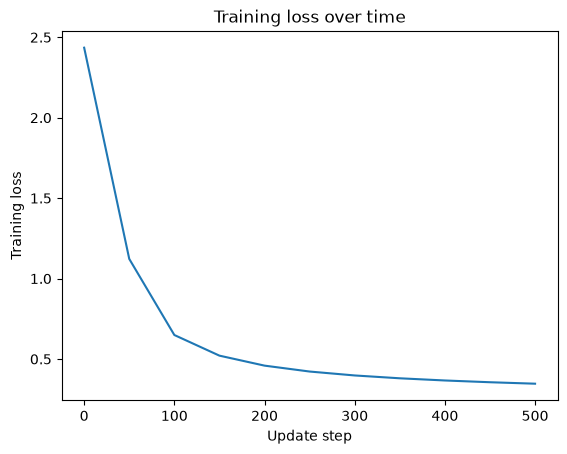

In [24]:
# Start again from a fresh initialization and use all 50,000 training examples.
parameters, history = train(
    X_train,
    y_train,
    hidden_size=10,
    learning_rate=0.1,
    steps=500,
    log_every=50,
)

train_loss, train_accuracy = evaluate(X_train, y_train, parameters)
validation_loss, validation_accuracy = evaluate(X_validation, y_validation, parameters)

print("Final training:", train_loss, train_accuracy)
print("Final validation:", validation_loss, validation_accuracy)

# Plot the recorded learning trajectory.
plt.plot(history[:, 0], history[:, 1])
plt.xlabel("Update step")
plt.ylabel("Training loss")
plt.title("Training loss over time")
plt.show()

In [25]:
# Change only one of these values per run and record the validation result.
experiment_name = "hidden width 32"
experiment_hidden_size = 32
experiment_learning_rate = 0.1

experiment_parameters, _ = train(
    X_train,
    y_train,
    hidden_size=experiment_hidden_size,
    learning_rate=experiment_learning_rate,
    steps=500,
    log_every=100,
    seed=SEED,  # Same seed keeps the comparison fairer.
)

experiment_loss, experiment_accuracy = evaluate(
    X_validation, y_validation, experiment_parameters
)

print(experiment_name)
print("Validation loss:", experiment_loss)
print("Validation accuracy:", experiment_accuracy)

step    0 | loss 2.4004 | accuracy 0.131
step  100 | loss 0.4991 | accuracy 0.871
step  200 | loss 0.3868 | accuracy 0.893
step  300 | loss 0.3435 | accuracy 0.903
step  400 | loss 0.3179 | accuracy 0.909
step  500 | loss 0.2996 | accuracy 0.915
hidden width 32
Validation loss: 0.30100277
Validation accuracy: 0.9132


Test loss: 0.28596845
Test accuracy: 0.9199


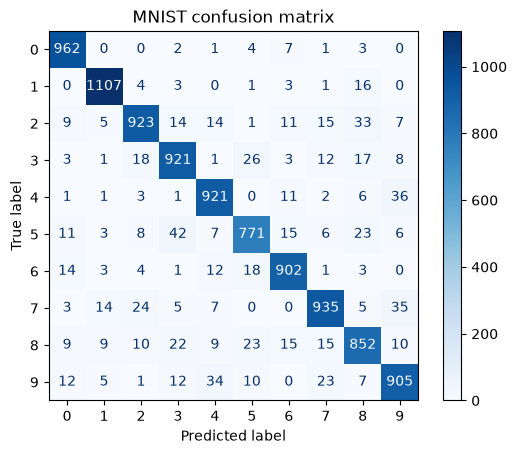

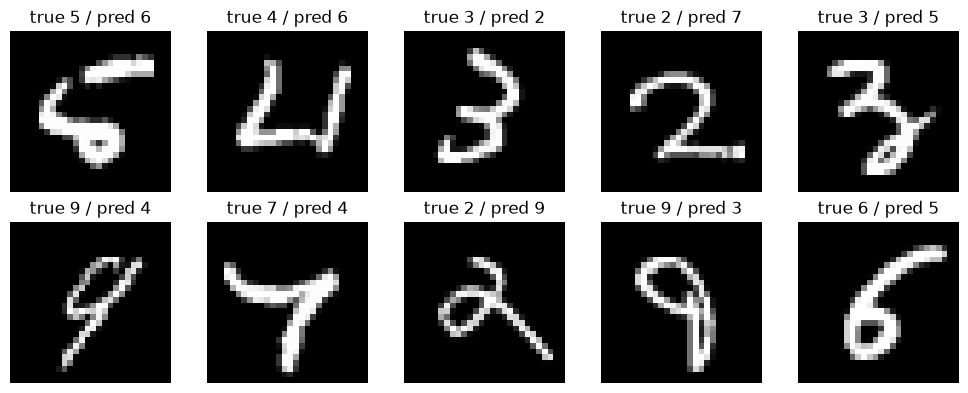

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

final_parameters = experiment_parameters  # Replace only if a validation experiment was clearly better.

# Use the test set now that model choices are finished.
test_probabilities, _ = forward(X_test, final_parameters)
test_predictions = np.argmax(test_probabilities, axis=0)
test_loss = cross_entropy(test_probabilities, y_test)
test_accuracy = np.mean(test_predictions == y_test)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

# Summarize which digits are confused.
matrix = confusion_matrix(y_test, test_predictions)
ConfusionMatrixDisplay(matrix).plot(cmap="Blues")
plt.title("MNIST confusion matrix")
plt.show()

# Display the first ten mistakes with correct and predicted labels.
mistake_indices = np.flatnonzero(test_predictions != y_test)[:10]
figure, axes = plt.subplots(2, 5, figsize=(10, 4))

for axis, index in zip(axes.flat, mistake_indices):
    axis.imshow(X_test[:, index].reshape(28, 28), cmap="gray")
    axis.set_title(f"true {y_test[index]} / pred {test_predictions[index]}")
    axis.axis("off")

plt.tight_layout()
plt.show()